# Gradient Boosting ??? Model Development Workflow

> **MLCourse ?? Machine Learning ?? supervised ?? classification**

Production tuning on REAL breast-cancer data (`data/breast_cancer.csv`):
staged curves expose the overfit point; joint lr??depth??subsample search;
calibration check before trusting probabilities.

## What you'll learn
- `staged_predict` ??? find the round where test peaks (free early stopping)
- Why lr/depth/subsample must be tuned TOGETHER
- Calibration quick-check for probability outputs

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

## 2. Data loading (OpenML edition cached by earlier modules)

In [2]:
bc = pd.read_csv(ML_ROOT / "data" / "breast_cancer.csv")
bc.columns = [c.strip().lower().replace(" ", "_") for c in bc.columns]
bc["target"] = (bc["class"] == "malignant").astype(int)
bc = bc.drop(columns="class")
for c in bc.columns[bc.isna().any()]:            # OpenML copy has a few NaNs
    bc[c] = bc[c].fillna(bc[c].median())

y = bc.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(bc.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

gbm = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                 max_depth=2, subsample=0.8,
                                 random_state=42).fit(X_tr, y_tr)
pred = gbm.predict(X_te)
print(f"test acc {accuracy_score(y_te, pred):.4f}")
cv = cross_val_score(gbm, X_tr, y_tr, cv=5).mean()
print(f"CV acc   {cv:.4f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

test acc 0.9543


CV acc   0.9657


,pred malignant,pred benign
true malignant,112,3
true benign,5,55


## 3. Staged curves locate the sweet round

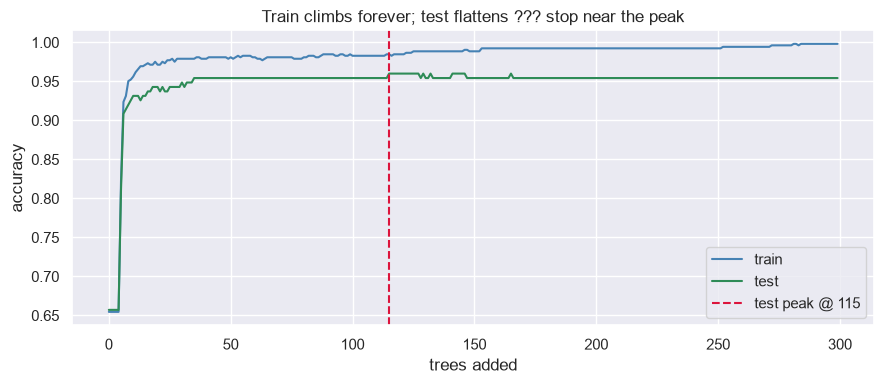

early stopping would pick n???115 of 300


In [3]:
st_tr = [accuracy_score(y_tr, (p[:, 1] >= .5).astype(int))   # accuracy per round
         for p in gbm.staged_predict_proba(X_tr)]
st_te = [accuracy_score(y_te, (p[:, 1] >= .5).astype(int))
         for p in gbm.staged_predict_proba(X_te)]
best_round = int(np.argmax(st_te))

plt.figure(figsize=(9, 4))
plt.plot(st_tr, label="train", color="steelblue")
plt.plot(st_te, label="test", color="seagreen")
plt.axvline(best_round, ls="--", c="crimson",
            label=f"test peak @ {best_round}")
plt.xlabel("trees added"); plt.ylabel("accuracy"); plt.legend()
plt.title("Train climbs forever; test flattens ??? stop near the peak")
plt.tight_layout(); plt.show()
print(f"early stopping would pick n???{best_round} of 300")

## 4. Interaction grid: lr ?? depth ?? subsample

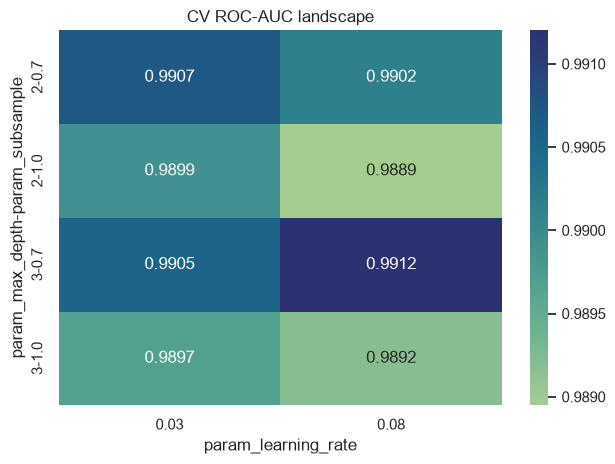

best: {'learning_rate': 0.08, 'max_depth': 3, 'subsample': 0.7} | CV AUC 0.9912


In [4]:
grid = GridSearchCV(
    GradientBoostingClassifier(n_estimators=250, random_state=42),
    {"learning_rate": [0.03, 0.08],
     "max_depth": [2, 3],
     "subsample": [0.7, 1.0]},
    cv=5, n_jobs=-1, scoring="roc_auc")
grid.fit(X_tr, y_tr)

res = pd.DataFrame(grid.cv_results_)
pivot = res.pivot_table(index=["param_max_depth", "param_subsample"],
                        columns="param_learning_rate", values="mean_test_score")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="crest")
plt.title("CV ROC-AUC landscape"); plt.tight_layout(); plt.show()
print("best:", grid.best_params_, f"| CV AUC {grid.best_score_:.4f}")

## 5. Calibration ??? can we trust .predict_proba?

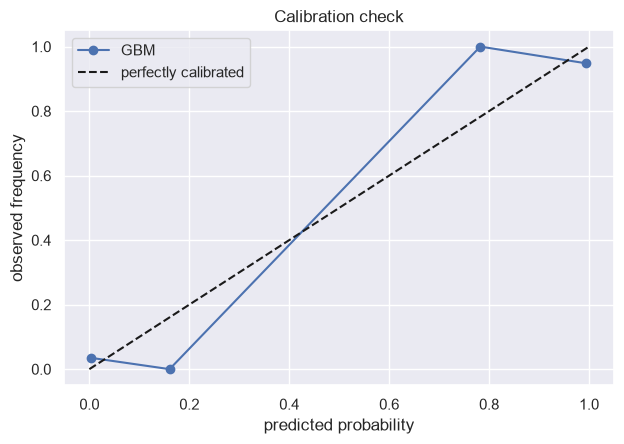

below-diagonal points = over-confident; fix via CalibratedClassifierCV.


In [5]:
proba = grid.best_estimator_.predict_proba(X_te)[:, 1]
frac_pos, mean_pred = calibration_curve(y_te, proba, n_bins=8)

plt.figure(figsize=(6.4, 4.6))
plt.plot(mean_pred, frac_pos, "o-", label="GBM")
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
plt.legend(); plt.title("Calibration check"); plt.tight_layout(); plt.show()
print("below-diagonal points = over-confident; fix via CalibratedClassifierCV.")

## Summary & key takeaways

- Staged curves = built-in early-stopping guidance.
- lr??? pairs with rounds??? and shallow depth (2???3).
- subsample < 1 often buys a hair of extra CV score.
- Calibrate probabilities before pricing risk with them.